# Time Series Monitoring of Turbidity and Chlorophyll-A

* **Products used:** 
[wq_annual](https://explorer.digitalearth.africa/products/wq_annual), 
[ls5_sr](https://explorer.digitalearth.africa/products/ls5_sr),
[ls7_sr](https://explorer.digitalearth.africa/products/ls7_sr),
[ls8_sr](https://explorer.digitalearth.africa/products/ls8_sr),
[ls9_sr](https://explorer.digitalearth.africa/products/ls9_sr),
[s2_l2a](https://explorer.digitalearth.africa/products/s2_l2a)

## Background
The Water Quality Monitoring Service (WQMS) dataset notebook introduces the several variables available in the _annual_ water quality product. However, one may want to monitor these variables on shorter time scales. 

## Description
This notebook shows how to monitor the Total Suspended Matter (TSM), a proxy for the turbidity, and Chlorophyll-A, on an individual scene basis and aggregate into monthly spatial medians.

1. [Load in annual data](#Load-in-annual-data)
2. [Apply algorithms to individual timesteps](#Apply-algorithms-to-individual-timesteps)
3. [Plot time series](#Plot-time-series)

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import datacube
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from deafrica_tools.plotting import display_map
from deafrica_tools.datahandling import load_ard

import sys
sys.path.append("/home/jovyan/deafrica_water_quality/src")
from water_quality.mapping.fai import FAI
from water_quality.mapping.algorithms import set_wq_algorithms, run_wq_algorithms, harmonize_wq_variables, normalize_wq_variables, compute_trophic_state_index
from water_quality.mapping.pixel_correction import R_correction

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app='TSM_Chla_monitoring')

## Load in annual data
First we load in data from the [wq_annual](https://explorer.digitalearth.africa/products/wq_annual) product to form a yearly baseline. 
The default location is Lake Manyara in northern Tanzania. 

In [3]:
query = {
    "product": "wq_annual",
    "x": (35.72, 35.92),
    "y": (-3.90, -3.35),
    "crs": "EPSG:4326",
    "time": ("2020-01-01", "2025-12-31"),
    "output_crs": "EPSG:6933",
    "resolution": (-10, 10),
    "measurements": [
        "tsm",           # Turbidity
        "chla",          # Chlorophyll-A
        "tsi",           # Trophic State Index
        "clear_water",   # Clear water mask
        "water_mask",    # Water presence mask
    ]
}

In [4]:
display_map(x=query["x"], y=query["y"])

In [5]:
ds = dc.load(**query)

## Apply algorithms to individual timesteps
For short-term monitoring we load in the full set of observations available in DE Africa from the TM, OLI and MSI sensors.

### Load satellite scenes in time period

In [6]:
# Dictionary to map load_ard bands to those used by water_quality package
measurements = {
    'oli': {
        'blue': 'oli02',
        'green': 'oli03',
        'red': 'oli04',
        'nir': 'oli05',
        'swir_1': 'oli06',
        'swir_2': 'oli07',
        'pixel_quality': 'oli_pq'
    },
    'msi': {
        'blue': 'msi02',
        'green': 'msi03',
        'red': 'msi04',
        'red_edge_1': 'msi05',
        'red_edge_2': 'msi06',
        'red_edge_3': 'msi07',
        'nir': 'msi08',
        'nir_narrow': 'msi8a',
        'swir_1': 'msi11',
        'swir_2': 'msi12',
        'qa': 'msi_pq'
    },
    'tm': {
        'blue': 'tm01',
        'green': 'tm02',
        'red': 'tm03',
        'nir': 'tm04',
        'swir_1': 'tm05',
        'swir_2': 'tm07',
        'pixel_quality': 'tm_pq'
    }
}

In [7]:
# Map sensors to products
products = {
    "tm": ["ls5_sr", "ls7_sr"],
    "oli": ["ls8_sr", "ls9_sr"],
    "msi": ["s2_l2a"],
}

In [8]:
# Sensor end dates
SENSOR_END_DATES = {
    "tm": "2023-12-31",  # Landsat 7 science imaging was suspended in Jan 2024
    "oli": None,         # Landsat 8/9 (ongoing)
    "msi": None          # Sentinel-2 (ongoing)
}

In [9]:
# Dictionary to store each sensor dataset
ds_list = {}

x_range = (35.72, 35.92)
y_range = (-3.90, -3.35) # Lake Manyara
start_time = "2023-01-01"
end_time   = "2025-12-31"

for sensor in products.keys():

    print(f"Loading {sensor} products: {products[sensor]}")

    sensor_end = SENSOR_END_DATES[sensor]
    effective_end = min(end_time, sensor_end) if sensor_end else end_time

    if start_time > effective_end:
        print(f"Skipping {sensor} (no valid time range)")
        continue

    print(f"Loading {sensor}")
    print(f"time: {start_time} → {effective_end}")

    ds_list[sensor] = load_ard(
        dc=dc,
        products=products[sensor],
        x=x_range,
        y=y_range,
        time=(start_time, effective_end),
        output_crs="EPSG:6933",
        resolution=(-480,480),
        verbose=True,
        dask_chunks={},
        measurements=list(measurements[sensor].keys())
    ).rename(measurements[sensor])

    # Get the QA band name from measurements dict
    qa_band = measurements[sensor].get("qa") or measurements[sensor].get("pixel_quality")

    # Scale reflectance bands only (skip QA/pixel quality)
    bands_to_scale = [b for b in ds_list[sensor].data_vars if b != qa_band]
    if sensor in ["tm", "oli"]:
        ds_list[sensor][bands_to_scale] = ds_list[sensor][bands_to_scale] * 10000

    print(f"Finished loading {sensor}")

Loading tm products: ['ls5_sr', 'ls7_sr']
Loading tm
time: 2023-01-01 → 2023-12-31
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls5_sr
    ls7_sr
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 52 time steps as a dask array
Finished loading tm
Loading oli products: ['ls8_sr', 'ls9_sr']
Loading oli
time: 2023-01-01 → 2025-12-31
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls8_sr


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:565: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_data, ds_masks])


    ls9_sr
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 496 time steps as a dask array
Finished loading oli
Loading msi products: ['s2_l2a']
Loading msi
time: 2023-01-01 → 2025-12-31
Using pixel quality parameters for Sentinel 2
Finding datasets
    s2_l2a


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:565: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_data, ds_masks])


Applying pixel quality/cloud mask
Returning 983 time steps as a dask array
Finished loading msi


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:565: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_data, ds_masks])


### Apply TSM and CHLA algorithms
We provide optional functions to calibrate values to in-situ data, the derivation of which is highlighted in the [DE Africa Water Quality User Guide](https://docs.digitalearthafrica.org/en/latest/data_specs/Water_Quality_specs.html). The user may wish to modify these functions.

In [10]:
def calibrate_tsm(data):
    return(-2.0559+.5824*data)

In [11]:
def calibrate_chla(data):
    return(-27.342+2.0894*data)

In [12]:
suffix = ""  # No suffix for individual time steps
ALGORITHMS_CHLA, ALGORITHMS_TSM = set_wq_algorithms(suffix)

Next we apply the processing steps.

In [13]:
%%time 

ds_dict_tsm = {}

for sensor in products.keys():
    print(sensor)
    print("Aligning clear water mask...")
    water_mask_aligned = ds.clear_water.reindex_like(ds_list[sensor], method="nearest")
    
    print("Applying Rayleigh correction...")
    ds_corrected = R_correction(ds_list[sensor], water_mask_aligned, instrument=sensor, drop=True)

    print("Applying clear water mask...")
    ds_masked = ds_corrected.where(water_mask_aligned)

    print("Applying TSM algorithm...")
    tsm_ds = run_wq_algorithms(
        instrument_data={sensor: ds_masked},
        algorithms_group=ALGORITHMS_TSM
    )

    print("Applying harmonisation...")
    tsm_ds = harmonize_wq_variables(tsm_ds)

    print("Applying normalisation...")
    tsm_ds = normalize_wq_variables(tsm_ds)

    print("Applying calibration...")
    for var in tsm_ds.data_vars:
        tsm_ds[var] = calibrate_tsm(tsm_ds[var])

    ds_dict_tsm[sensor] = tsm_ds
    
    print(f"Finished {sensor}\n")

tm
Aligning clear water mask...
Applying Rayleigh correction...
Applying clear water mask...
Applying TSM algorithm...
Applying harmonisation...


/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/v

Applying normalisation...
Applying calibration...
Finished tm

oli
Aligning clear water mask...
Applying Rayleigh correction...
Applying clear water mask...
Applying TSM algorithm...
Applying harmonisation...
Applying normalisation...
Applying calibration...
Finished oli

msi
Aligning clear water mask...
Applying Rayleigh correction...


Variable msi01 expected but not found in the dataset - (non-fatal error) for instrument msi


Applying clear water mask...
Applying TSM algorithm...
Applying harmonisation...
Applying normalisation...
Applying calibration...
Finished msi

CPU times: user 2min 56s, sys: 12.1 s, total: 3min 8s
Wall time: 16min 59s


In [14]:
%%time 

ds_dict_chla = {}

for sensor in products.keys():
    print(sensor)
    print("Aligning clear water mask...")
    water_mask_aligned = ds.clear_water.reindex_like(ds_list[sensor], method="nearest")
    
    print("Applying Rayleigh correction...")
    ds_corrected = R_correction(ds_list[sensor], water_mask_aligned, instrument=sensor, drop=True)

    print("Applying clear water mask...")
    ds_masked = ds_corrected.where(water_mask_aligned)
    
    print("Applying Chla algorithm...")
    chla_ds = run_wq_algorithms(
        instrument_data={sensor: ds_masked},
        algorithms_group=ALGORITHMS_CHLA
    )

    print("Applying harmonisation...")
    chla_ds = harmonize_wq_variables(chla_ds)

    print("Applying normalisation...")
    chla_ds = normalize_wq_variables(chla_ds)

    print("Applying calibration...")
    for var in chla_ds.data_vars:
        chla_ds[var] = calibrate_chla(chla_ds[var])

    ds_dict_chla[sensor] = chla_ds

    print(f"Finished {sensor}\n")

tm
Aligning clear water mask...
Applying Rayleigh correction...
Applying clear water mask...
Applying Chla algorithm...
Applying harmonisation...


Variable oli01 expected but not found in the dataset - (non-fatal error) for instrument oli


Applying normalisation...
Applying calibration...
Finished tm

oli
Aligning clear water mask...
Applying Rayleigh correction...
Applying clear water mask...
Applying Chla algorithm...
Applying harmonisation...


Variable msi01 expected but not found in the dataset - (non-fatal error) for instrument msi


Applying normalisation...
Applying calibration...
Finished oli

msi
Aligning clear water mask...
Applying Rayleigh correction...
Applying clear water mask...
Applying Chla algorithm...
Applying harmonisation...
Applying normalisation...
Applying calibration...
Finished msi

CPU times: user 3min 5s, sys: 12.3 s, total: 3min 17s
Wall time: 17min 8s


In [15]:
tsm_ds = xr.concat(ds_dict_tsm.values(), dim="time").sortby("time")

In [16]:
tsm_da = tsm_ds.to_stacked_array(
new_dim="tsm_measures", # new dimension for stacking
sample_dims=["time", "y", "x"], # keep spatial+temporal dims
variable_dim="tsm_wq_vars", # names of the algorithms
name="tsm"
)

In [17]:
tsm_final = tsm_da.median(dim="tsm_measures")

In [18]:
tsm_monthly = tsm_final.resample(time="1M").mean()

In [19]:
tsm_month_median = tsm_monthly.median(dim=("x", "y"))

In [20]:
chla_ds = xr.concat(ds_dict_chla.values(), dim="time").sortby("time")

In [21]:
chla_da = chla_ds.to_stacked_array(
new_dim="chla_measures", # new dimension for stacking
sample_dims=["time", "y", "x"], # keep spatial+temporal dims
variable_dim="chla_wq_vars", # names of the algorithms
name="chla"
)

In [22]:
chla_final = chla_da.median(dim="chla_measures")

In [23]:
tsi_final = compute_trophic_state_index(chla_final)

In [24]:
chla_monthly = chla_final.resample(time="1M").mean()

In [25]:
chla_month_median = chla_monthly.median(dim=("x", "y"))

In [33]:
chla_ds

<xarray.Dataset> Size: 1GB
Dimensions:            (time: 1531, y: 147, x: 41)
Coordinates:
  * time               (time) datetime64[ns] 12kB 2023-01-02T07:50:10.923070 ...
  * y                  (y) float64 1kB -4.27e+05 -4.274e+05 ... -4.97e+05
  * x                  (x) float64 328B 3.447e+06 3.447e+06 ... 3.466e+06
    spatial_ref        int32 4B 6933
Data variables: (12/16)
    ndci_tm43          (time, y, x) float64 74MB nan nan nan nan ... nan nan nan
    chla_3bda_tm       (time, y, x) float64 74MB nan nan nan nan ... nan nan nan
    chla_tebbs_tm      (time, y, x) float64 74MB nan nan nan nan ... nan nan nan
    chla_modis2b_tm    (time, y, x) float64 74MB nan nan nan nan ... nan nan nan
    ndci_oli54         (time, y, x) float64 74MB 44.07 nan 50.35 ... nan nan nan
    chla_3bda_oli      (time, y, x) float64 74MB 44.42 nan 55.25 ... nan nan nan
    ...                 ...
    chla_toming_msi    (time, y, x) float64 74MB nan nan nan nan ... nan nan nan
    chla_gurlin2b_msi  (time, y, x) float64 74MB nan nan nan nan ... nan nan nan
    chla_3bda_msi      (time, y, x) float64 74MB nan nan nan nan ... nan nan nan
    chla_tebbs_msi     (time, y, x) float64 74MB nan nan nan nan ... nan nan nan
    chla_meris2b_msi   (time, y, x) float64 74MB nan nan nan nan ... nan nan nan
    chla_modis2b_msi   (time, y, x) float64 74MB nan nan nan nan ... nan nan nan

### Plot time series

In [27]:
# Calibrate yearly data
ds["tsm"] = calibrate_tsm(ds.tsm)

In [28]:
ds["chla"] = calibrate_chla(ds.chla)

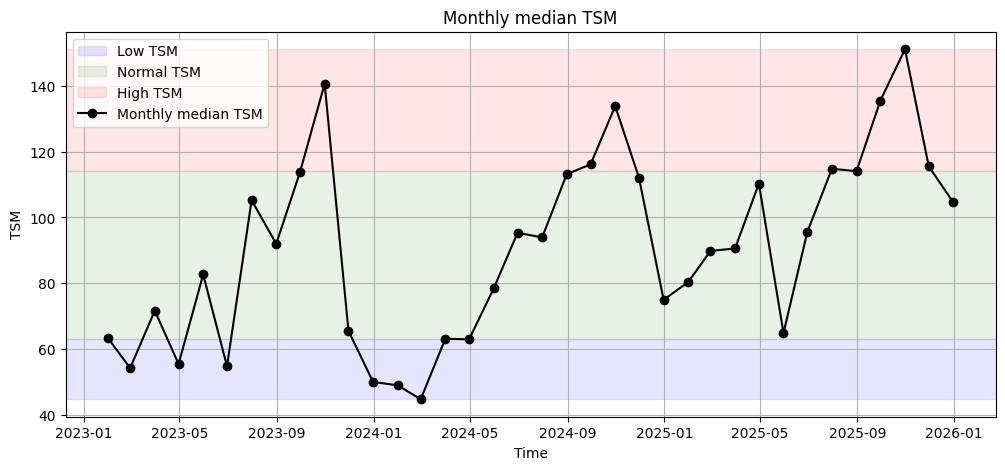

In [29]:
Q = np.array([0, 0.21, 0.79, 1])
quantile_vals = tsm_month_median.quantile(Q, skipna=True).values

# Labels and RGBA colors with alpha=0.1
labels = ["Low", "Normal", "High"]
colors = {
    "Low": "rgba(0, 0, 255, 0.1)",    # blue
    "Normal": "rgba(0, 128, 0, 0.1)", # green
    "High": "rgba(255, 0, 0, 0.1)"    # red
}

# Create classes array
classes = xr.full_like(tsm_month_median, np.nan, dtype=object)
valid = tsm_month_median.notnull()
class_index = np.digitize(tsm_month_median.values[valid], quantile_vals[1:-1])
classes.values[valid] = np.array(labels)[class_index]

# Step 2: Filter for 2020 onwards
time_mask = tsm_month_median.time.dt.year >= 2020
tsm_month_median_filtered = tsm_month_median.sel(time=time_mask)

# Step 3: Remove NaNs for monthly plot
valid = ~np.isnan(tsm_month_median_filtered.values)
x = tsm_month_median_filtered.time.values[valid]
y = tsm_month_median_filtered.values[valid]

labels = ["low", "normal", "high"]
colors = ["blue", "green", "red"]
alphas = [0.1, 0.1, 0.1]

plt.figure(figsize=(12,5))

# Step 4: Horizontal bands
plt.axhspan(quantile_vals[0], quantile_vals[1], color=colors[0], alpha=alphas[0], label="Low TSM")
plt.axhspan(quantile_vals[1], quantile_vals[2], color=colors[1], alpha=alphas[1], label="Normal TSM")
plt.axhspan(quantile_vals[2], quantile_vals[3], color=colors[2], alpha=alphas[2], label="High TSM")

# Step 5: Step plot for yearly spatial median, filtered for 2020 onwards
# yearly_mask = ds.tsm.time.dt.year >= 2017
# plt.step(
#     ds.tsm.time.values[yearly_mask],
#     ds.tsm.median(dim=("x","y")).values[yearly_mask],
#     where="post",
#     label="Yearly spatial median"
# )

# Step 6: Plot monthly median (skip NaNs)
plt.plot(x, y, marker="o", color="black", label="Monthly median TSM")

plt.xlabel("Time")
plt.ylabel("TSM")
plt.title("Monthly median TSM")
plt.legend()
plt.grid(True)
plt.show()

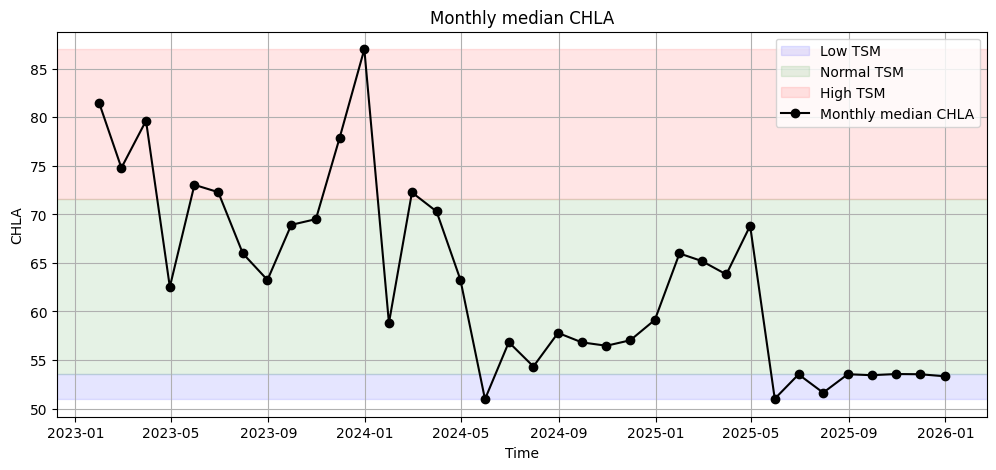

In [34]:
Q = np.array([0, 0.21, 0.79, 1])
quantile_vals = chla_month_median.quantile(Q, skipna=True).values

# Step 2: Filter for 2020 onwards
time_mask = chla_month_median.time.dt.year >= 2020
chla_month_median_filtered = chla_month_median.sel(time=time_mask)

# Step 3: Remove NaNs for monthly plot
valid = ~np.isnan(chla_month_median_filtered.values)
x = chla_month_median_filtered.time.values[valid]
y = chla_month_median_filtered.values[valid]

labels = ["low", "normal", "high"]
colors = ["blue", "green", "red"]
alphas = [0.1, 0.1, 0.1]

plt.figure(figsize=(12,5))

# Step 4: Horizontal bands
plt.axhspan(quantile_vals[0], quantile_vals[1], color=colors[0], alpha=alphas[0], label="Low TSM")
plt.axhspan(quantile_vals[1], quantile_vals[2], color=colors[1], alpha=alphas[1], label="Normal TSM")
plt.axhspan(quantile_vals[2], quantile_vals[3], color=colors[2], alpha=alphas[2], label="High TSM")

# # Step 5: Step plot for yearly spatial median, filtered for 2020 onwards
# yearly_mask = ds.tsm.time.dt.year >= 2017
# plt.step(
#     ds.chla.time.values[yearly_mask],
#     ds.chla.median(dim=("x","y")).values[yearly_mask],
#     where="post",
#     label="Yearly spatial median"
# )

# Step 6: Plot monthly median (skip NaNs)
plt.plot(x, y, marker="o", color="black", label="Monthly median CHLA")

plt.xlabel("Time")
plt.ylabel("CHLA")
plt.title("Monthly median CHLA")
plt.legend()
plt.grid(True)
plt.show()

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [35]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [36]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-03-20'